**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [3]:
import torch
import numpy as np

In [4]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [5]:
inputs_tensor = torch.tensor(inputs)
targets_tensor = torch.tensor(targets)
print(inputs_tensor)
print(targets_tensor)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [7]:
torch.random.manual_seed(1)

In [8]:
w = torch.randn(1, 3, requires_grad=True)
b = torch.randn(1, requires_grad=True)
print("w:", w)
print("b:", b)

w: tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
b: tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [10]:
def sigmoid(z):
    """Сигмоїдна функція активації"""
    return 1 / (1 + torch.exp(-z))

def model(x, w, b):
    """Логістична регресія: sigma(x @ w.T + b)"""
    z = x @ w.t() + b  
    return sigmoid(z)

# Обчислення передбачень з поточними вагами
preds = model(inputs_tensor, w, b)
print("Передбачення:")
print(preds)
print()
print("Аналіз: всі передбачення = 1.0 - модель 'надто впевнена' ще до навчання.")
print("Причина: великі випадкові ваги -> великі значення z -> сигмоїда насичується.")

Передбачення:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)

Аналіз: всі передбачення = 1.0 - модель 'надто впевнена' ще до навчання.
Причина: великі випадкові ваги -> великі значення z -> сигмоїда насичується.


4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [12]:
def binary_cross_entropy(predicted_probs, true_labels):
    """
    Обчислює BCE loss: -mean(y*log(p) + (1-y)*log(1-p))
    """
    # Клампуємо ймовірності щоб уникнути log(0)
    eps = 1e-7
    predicted_probs = torch.clamp(predicted_probs, eps, 1 - eps)
    loss_per_sample = -(true_labels * torch.log(predicted_probs) +
                        (1 - true_labels) * torch.log(1 - predicted_probs))
    return torch.mean(loss_per_sample)

loss = binary_cross_entropy(preds, targets_tensor)
print("Loss (Binary Cross-Entropy):", loss)

Loss (Binary Cross-Entropy): tensor(6.3770, grad_fn=<MeanBackward0>)


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [14]:
loss.backward()
print("Градієнти w.grad:")
print(w.grad)
print()
print("Градієнти b.grad:")
print(b.grad)

Градієнти w.grad:
tensor([[0., 0., 0.]])

Градієнти b.grad:
tensor([0.])


**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [17]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True) 
b = torch.randn(1, requires_grad=True) 

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [18]:
preds = model(inputs_tensor, w, b)
print("Передбачення (ймовірності):")
print(preds)
print()

loss = binary_cross_entropy(preds, targets_tensor)
print("Loss:", loss)

# Обнулюємо старі градієнти перед новим backward
if w.grad is not None:
    w.grad.zero_()
if b.grad is not None:
    b.grad.zero_()

loss.backward()
print()
print("Градієнти w.grad:")
print(w.grad)
print("Градієнти b.grad:")
print(b.grad)

Передбачення (ймовірності):
tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)

Loss: tensor(0.6829, grad_fn=<MeanBackward0>)

Градієнти w.grad:
tensor([[ -5.4417, -18.9853, -10.0682]])
Градієнти b.grad:
tensor([-0.0794])


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [20]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)
b = torch.randn(1, requires_grad=True)
w.data = w.data / 10000
b.data = b.data / 10000

learning_rate = 1e-3
num_epochs = 1000

for epoch in range(num_epochs):
    # 1. Генерація прогнозів
    preds = model(inputs_tensor, w, b)

    # 2. Обчислення втрат
    loss = binary_cross_entropy(preds, targets_tensor)

    # 3. Обчислення градієнтів
    loss.backward()

    # 4. Оновлення ваг
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 5. Скидання градієнтів
    w.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print()
print("Фінальні передбачення (ймовірності):")
final_preds = model(inputs_tensor, w, b)
print(final_preds.detach())
print()
print("Передбачені класи (поріг 0.5):")
print((final_preds >= 0.5).int().detach())
print()
print("Справжні мітки:")
print(targets_tensor.int())

Epoch [200/1000], Loss: 0.1624
Epoch [400/1000], Loss: 0.1198
Epoch [600/1000], Loss: 0.0937
Epoch [800/1000], Loss: 0.0763
Epoch [1000/1000], Loss: 0.0640

Фінальні передбачення (ймовірності):
tensor([[1.6792e-01],
        [8.7485e-01],
        [9.9771e-01],
        [2.3260e-07],
        [9.9999e-01]])

Передбачені класи (поріг 0.5):
tensor([[0],
        [1],
        [1],
        [0],
        [1]], dtype=torch.int32)

Справжні мітки:
tensor([[0],
        [1],
        [1],
        [0],
        [1]], dtype=torch.int32)


Вцілому прогнози непогані. Вийшла лише одна помилка в передбаченні, яку можна вирішити шляхом зміщенння порогу до 0.6

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [23]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [25]:
# Нормалізуємо вхідні дані, адже без цього навіть малі ваги дадуть великі z через великі значення ознак
inputs_mean = inputs.mean(axis=0)
inputs_std = inputs.std(axis=0)
inputs_norm = (inputs - inputs_mean) / inputs_std

inputs_tensor_2 = torch.tensor(inputs_norm)
targets_tensor_2 = torch.tensor(targets)
print(inputs_tensor_2)
print(targets_tensor_2)

tensor([[-0.9453, -0.6121, -0.9120],
        [ 0.5473,  0.0790,  0.7680],
        [ 0.2156,  1.5927,  0.2880],
        [ 1.4594, -1.4019, -1.3920],
        [-1.2770,  0.3422,  1.2480],
        [-0.9453, -0.6121, -0.9120],
        [ 0.5473,  0.0790,  0.7680],
        [ 0.2156,  1.5927,  0.2880],
        [ 1.4594, -1.4019, -1.3920],
        [-1.2770,  0.3422,  1.2480],
        [-0.9453, -0.6121, -0.9120],
        [ 0.5473,  0.0790,  0.7680],
        [ 0.2156,  1.5927,  0.2880],
        [ 1.4594, -1.4019, -1.3920],
        [-1.2770,  0.3422,  1.2480]])
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])


In [26]:
from torch.utils.data import TensorDataset
train_ds = TensorDataset(inputs_tensor_2, targets_tensor_2)
print("Перші 3 елементи датасету:")
print(train_ds[0:3])

Перші 3 елементи датасету:
(tensor([[-0.9453, -0.6121, -0.9120],
        [ 0.5473,  0.0790,  0.7680],
        [ 0.2156,  1.5927,  0.2880]]), tensor([[0.],
        [1.],
        [1.]]))


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [28]:
from torch.utils.data import DataLoader

# Визначаємо data loader
batch_size = 5
train_dl = DataLoader(train_ds, batch_size, shuffle=True)
next(iter(train_dl))

[tensor([[-0.9453, -0.6121, -0.9120],
         [ 0.5473,  0.0790,  0.7680],
         [ 1.4594, -1.4019, -1.3920],
         [-1.2770,  0.3422,  1.2480],
         [ 1.4594, -1.4019, -1.3920]]),
 tensor([[0.],
         [1.],
         [0.],
         [1.],
         [0.]])]

9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [30]:
import torch.nn as nn

class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model = LogReg()
print("Модель LogReg:")
print(model)
print()
print("Ваги:", model.linear.weight)
print("Зсув:", model.linear.bias)

Модель LogReg:
LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Ваги: Parameter containing:
tensor([[ 0.2109, -0.2250, -0.0421]], requires_grad=True)
Зсув: Parameter containing:
tensor([-0.0520], requires_grad=True)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [32]:
import torch.nn.functional as F

opt = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = F.binary_cross_entropy

# Поточні втрати (до навчання)
current_preds = model(inputs_tensor_2)
current_loss = loss_fn(current_preds, targets_tensor_2)
print("Loss:", current_loss.item())

Loss: 0.8485196828842163


Loss досить значний, а отже моделі ще не вдалося навчитися

11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

Epoch [100/1000], Loss: 0.2440
Epoch [200/1000], Loss: 0.1378
Epoch [300/1000], Loss: 0.0956
Epoch [400/1000], Loss: 0.0730
Epoch [500/1000], Loss: 0.0589
Epoch [600/1000], Loss: 0.0494
Epoch [700/1000], Loss: 0.0424
Epoch [800/1000], Loss: 0.0372
Epoch [900/1000], Loss: 0.0331
Epoch [1000/1000], Loss: 0.0298


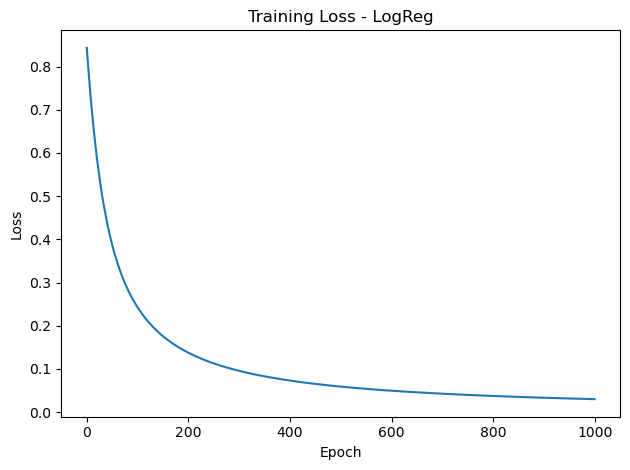


Передбачені ймовірності:
tensor([[0.0468],
        [0.9461],
        [0.9841],
        [0.0089],
        [0.9796],
        [0.0468],
        [0.9461],
        [0.9841],
        [0.0089],
        [0.9796],
        [0.0468],
        [0.9461],
        [0.9841],
        [0.0089],
        [0.9796]])

Передбачені класи (поріг 0.5):
tensor([[0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1]], dtype=torch.int32)

Справжні мітки:
tensor([[0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1]], dtype=torch.int32)


In [35]:
import matplotlib.pyplot as plt

def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0

        for xb, yb in train_dl:
            # Генеруємо передбачення
            pred = model(xb)

            # Обчислюємо втрати
            loss = loss_fn(pred, yb)

            # Виконуємо градієнтний спуск
            loss.backward()
            opt.step()
            opt.zero_grad()

            # Накопичуємо втрати
            total_loss += loss.item()

        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)

        # Виводимо підсумок епохи
        if (epoch + 1) % 100 == 0:
          print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

losses = fit_return_loss(1000, model, loss_fn, opt, train_dl)

# Графік зміни loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss - LogReg')
plt.tight_layout()
plt.show()

print("\nПередбачені ймовірності:")
final_preds = model(inputs_tensor_2)
print(final_preds.detach())

print("\nПередбачені класи (поріг 0.5):")
print((final_preds >= 0.5).int().detach())

print("\nСправжні мітки:")
print(targets_tensor_2.int())